# Vehicle Price Preprocessing (Ikman)
This notebook version is converted from `preprocessing.py`.
Run cells from top to bottom.

In [8]:
import re
from pathlib import Path

import numpy as np
import pandas as pd

CURRENT_YEAR = pd.Timestamp.today().year
EXPECTED_COLUMNS = [
    "url",
    "title_text",
    "price_lkr",
    "brand",
    "model",
    "year",
    "mileage_km",
    "fuel_type",
    "engine_capacity_cc",
    "transmission",
    "location",
]
NUMERIC_COLUMNS = ["price_lkr", "year", "mileage_km", "engine_capacity_cc"]
CATEGORICAL_COLUMNS = ["brand", "model", "fuel_type", "transmission", "location"]

In [9]:
def load_dataset(file_path: Path) -> pd.DataFrame:
    try:
        return pd.read_csv(file_path, low_memory=False)
    except UnicodeDecodeError:
        return pd.read_csv(file_path, encoding="latin-1", low_memory=False)


def normalize_text(series: pd.Series) -> pd.Series:
    normalized = (
        series.astype(str)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
        .replace({"": np.nan, "nan": np.nan, "None": np.nan})
    )
    return normalized


def extract_location_from_url(url: str | float | None) -> str | None:
    if not isinstance(url, str):
        return None
    url = url.strip()
    if not url:
        return None
    match = re.search(r"for-sale-([a-z\-]+)(?:-\d+)?$", url, flags=re.I)
    if not match:
        return None
    return match.group(1).replace("-", " ").title()


def ensure_expected_columns(df: pd.DataFrame) -> pd.DataFrame:
    for column in EXPECTED_COLUMNS:
        if column not in df.columns:
            df[column] = np.nan
    return df[EXPECTED_COLUMNS].copy()


def standardize_fuel_type(series: pd.Series) -> pd.Series:
    mapping = {
        "petrol": "Petrol",
        "gasoline": "Petrol",
        "diesel": "Diesel",
        "hybrid": "Hybrid",
        "electric": "Electric",
        "plugin hybrid": "Hybrid",
        "plug-in hybrid": "Hybrid",
        "phev": "Hybrid",
    }
    normalized = series.str.lower().str.strip().replace(mapping)
    return normalized.str.title().fillna("Unknown")


def standardize_transmission(series: pd.Series) -> pd.Series:
    mapping = {
        "auto": "Automatic",
        "automatic": "Automatic",
        "manual": "Manual",
        "tiptronic": "Tiptronic",
        "cvt": "Automatic",
    }
    normalized = series.str.lower().str.strip().replace(mapping)
    return normalized.str.title().fillna("Unknown")


def fill_brand_model_from_title(df: pd.DataFrame) -> pd.DataFrame:
    split_tokens = df["title_text"].fillna("").str.split()
    missing_brand = df["brand"].isna()
    missing_model = df["model"].isna()

    df.loc[missing_brand, "brand"] = split_tokens[missing_brand].str.get(0)
    df.loc[missing_model, "model"] = split_tokens[missing_model].str.get(1)
    return df


def impute_numeric_with_brand_median(df: pd.DataFrame, column: str) -> pd.DataFrame:
    brand_median = df.groupby("brand")[column].transform("median")
    df[column] = df[column].fillna(brand_median)
    df[column] = df[column].fillna(df[column].median())
    return df


def clip_quantile(series: pd.Series, low: float = 0.01, high: float = 0.99) -> pd.Series:
    lower = series.quantile(low)
    upper = series.quantile(high)
    return series.clip(lower=lower, upper=upper)


def preprocess(df: pd.DataFrame) -> pd.DataFrame:
    # Inspect structure
    df.columns = [col.strip() for col in df.columns]
    df = ensure_expected_columns(df)

    # Handle missing values
    for column in ["url", "title_text", *CATEGORICAL_COLUMNS]:
        df[column] = normalize_text(df[column])

    # Convert data types
    for column in NUMERIC_COLUMNS:
        df[column] = pd.to_numeric(df[column], errors="coerce")

    df = df.drop_duplicates(subset=["url"], keep="first")
    df = fill_brand_model_from_title(df)
    df["location"] = df["location"].fillna(df["url"].apply(extract_location_from_url))

    df["brand"] = df["brand"].str.title().fillna("Unknown")
    df["model"] = df["model"].str.title().fillna("Unknown")
    df["location"] = df["location"].str.title().fillna("Unknown")
    df["fuel_type"] = standardize_fuel_type(df["fuel_type"])

    df["transmission"] = standardize_transmission(df["transmission"])


    # Handle missing values
    df = df[df["price_lkr"].notna()]
    df = df[df["price_lkr"] > 0]
    df = df[df["year"].between(1950, CURRENT_YEAR + 1, inclusive="both")]
    df = df[df["mileage_km"].isna() | df["mileage_km"].between(0, 1_500_000)]
    df = df[df["engine_capacity_cc"].isna() | df["engine_capacity_cc"].between(50, 10_000)]

    df = impute_numeric_with_brand_median(df, "mileage_km")
    df = impute_numeric_with_brand_median(df, "engine_capacity_cc")

    # Handle outliers
    df["price_lkr"] = clip_quantile(df["price_lkr"])
    df["mileage_km"] = clip_quantile(df["mileage_km"])
    df["engine_capacity_cc"] = clip_quantile(df["engine_capacity_cc"])

    # Feature engineering (age etc.)
    df["vehicle_age"] = (CURRENT_YEAR - df["year"]).clip(lower=0)
    df["mileage_per_year"] = df["mileage_km"] / np.maximum(df["vehicle_age"], 1)

    ordered_columns = [
        "price_lkr",
        "brand",
        "model",
        "year",
        "mileage_km",
        "fuel_type",
        "engine_capacity_cc",
        "transmission",
        "location",
        "vehicle_age",
        "mileage_per_year",
    ]
    return df[ordered_columns].reset_index(drop=True)


def create_model_ready_dataset(df_clean: pd.DataFrame) -> pd.DataFrame:
    # Encode categorical variables
    model_df = df_clean.drop(columns=["url", "title_text"], errors="ignore")
    model_df = pd.get_dummies(
        model_df,
        columns=["brand", "model", "fuel_type", "transmission", "location"],
        dtype=int,
    )
    # Prepare final modelling dataset
    return model_df

In [10]:
input_path = Path("ikman_cars_dataset_Copy.csv")
model_output_path = Path("ikman_cars_preprocessed.csv")

raw_df = load_dataset(input_path)
clean_df = preprocess(raw_df)
model_df = create_model_ready_dataset(clean_df)

model_df.to_csv(model_output_path, index=False)

print(f"Input rows: {len(raw_df):,}")
print(f"Cleaned rows: {len(clean_df):,}")
print(f"Model-ready rows: {len(model_df):,}")
print(f"Saved model-ready dataset: {model_output_path}")

Input rows: 276
Cleaned rows: 260
Model-ready rows: 260
Saved model-ready dataset: ikman_cars_preprocessed.csv


In [11]:
clean_df.head(), model_df.head()

(    price_lkr   brand  model    year  mileage_km fuel_type  \
 0  16975000.0   Honda  Vezel  2023.0     10000.0    Hybrid   
 1  12250000.0   Honda    Crv  2013.0    169000.0    Petrol   
 2  28900000.0  Toyota  Hilux  2026.0         0.0    Diesel   
 3  24780000.0     Bmw   318I  2019.0     24000.0    Petrol   
 4  24790000.0     Bmw   318I  2019.0     24000.0    Petrol   
 
    engine_capacity_cc transmission location  vehicle_age  mileage_per_year  
 0              1500.0    Automatic  Colombo          3.0       3333.333333  
 1              1990.0    Automatic  Colombo         13.0      13000.000000  
 2              2800.0    Tiptronic  Colombo          0.0          0.000000  
 3              1500.0    Automatic  Colombo          7.0       3428.571429  
 4              1500.0    Automatic  Colombo          7.0       3428.571429  ,
     price_lkr    year  mileage_km  engine_capacity_cc  vehicle_age  \
 0  16975000.0  2023.0     10000.0              1500.0          3.0   
 1  12250

# Model Training: RandomForest Regressor for Price Prediction

Train and evaluate a RandomForestRegressor with GridSearchCV hyperparameter tuning.
- Split: 70% train / 15% validation / 15% test
- Tuning: GridSearchCV with 5-fold CV on training set
- Metrics: R², MAE, RMSE
- Outputs: Results table, predicted vs actual plot, feature importance plot

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Configuration
INPUT_FILE = Path("ikman_cars_preprocessed.csv")
RANDOM_STATE = 42
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

In [15]:
# Load the model-ready dataset
print("Loading preprocessed data...")
df = pd.read_csv(INPUT_FILE)
print(f"Dataset shape: {df.shape}")
print(f"Total features: {df.shape[1] - 1}\n")

# Separate target and features
y = df["price_lkr"]
X = df.drop(columns=["price_lkr"])

print(f"Target (price_lkr) shape: {y.shape}")
print(f"Features shape: {X.shape}")
print(f"First 10 features: {X.columns.tolist()[:10]}")
print(f"Price range: LKR {y.min():,.0f} - {y.max():,.0f}")

Loading preprocessed data...
Dataset shape: (260, 180)
Total features: 179

Target (price_lkr) shape: (260,)
Features shape: (260, 179)
First 10 features: ['year', 'mileage_km', 'engine_capacity_cc', 'vehicle_age', 'mileage_per_year', 'brand_Audi', 'brand_Bmw', 'brand_Byd', 'brand_Chery', 'brand_Chevrolet']
Price range: LKR 1,203,700 - 103,235,000


In [16]:
# Train/Validation/Test Split (70/15/15)
print("Splitting data into train/val/test (70/15/15)...\n")

# First split: 70% train, 30% temp (for val+test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=(VAL_RATIO + TEST_RATIO),
    random_state=RANDOM_STATE
)

# Second split: divide temp into val and test (50/50 of 30% = 15% each)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=RANDOM_STATE
)

print(f"Train set: {X_train.shape[0]:>4} samples ({100*len(X_train)/len(X):.1f}%)")
print(f"Validation set: {X_val.shape[0]:>4} samples ({100*len(X_val)/len(X):.1f}%)")
print(f"Test set: {X_test.shape[0]:>4} samples ({100*len(X_test)/len(X):.1f}%)")

Splitting data into train/val/test (70/15/15)...

Train set:  182 samples (70.0%)
Validation set:   39 samples (15.0%)
Test set:   39 samples (15.0%)


In [17]:
# Hyperparameter Tuning with GridSearchCV (5-fold CV on training set)
print("\nTuning hyperparameters with GridSearchCV (5-fold CV)...\n")

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 15, 20],
    "min_samples_split": [5, 10],
    "min_samples_leaf": [2, 4],
    "max_features": ["sqrt", "log2"],
}

rf_base = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)

grid_search = GridSearchCV(
    rf_base,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\n{'='*60}")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV R² score: {grid_search.best_score_:.4f}")
print(f"{'='*60}\n")

best_model = grid_search.best_estimator_


Tuning hyperparameters with GridSearchCV (5-fold CV)...

Fitting 5 folds for each of 48 candidates, totalling 240 fits

Best parameters: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Best CV R² score: 0.5157



In [18]:
# Evaluation Function & Results
def evaluate_model(model, X, y, dataset_name):
    y_pred = model.predict(X)
    r2 = r2_score(y, y_pred)
    mae = mean_absolute_error(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    
    return {
        "Dataset": dataset_name,
        "R² Score": r2,
        "MAE": mae,
        "RMSE": rmse,
        "Sample Count": len(y)
    }

print("Evaluating model on train/val/test sets...\n")

results_train = evaluate_model(best_model, X_train, y_train, "Train")
results_val = evaluate_model(best_model, X_val, y_val, "Validation")
results_test = evaluate_model(best_model, X_test, y_test, "Test")

# Create and display results table
results_df = pd.DataFrame([results_train, results_val, results_test])
print("="*85)
print("EVALUATION RESULTS")
print("="*85)
print(results_df.to_string(index=False))
print("="*85)

Evaluating model on train/val/test sets...

EVALUATION RESULTS
   Dataset  R² Score          MAE         RMSE  Sample Count
     Train  0.689859 6.454626e+06 1.047863e+07           182
Validation  0.491446 7.801515e+06 1.376580e+07            39
      Test  0.438509 7.441010e+06 8.974884e+06            39



Generating predicted vs actual scatter plot...
Saved: predicted_vs_actual.png


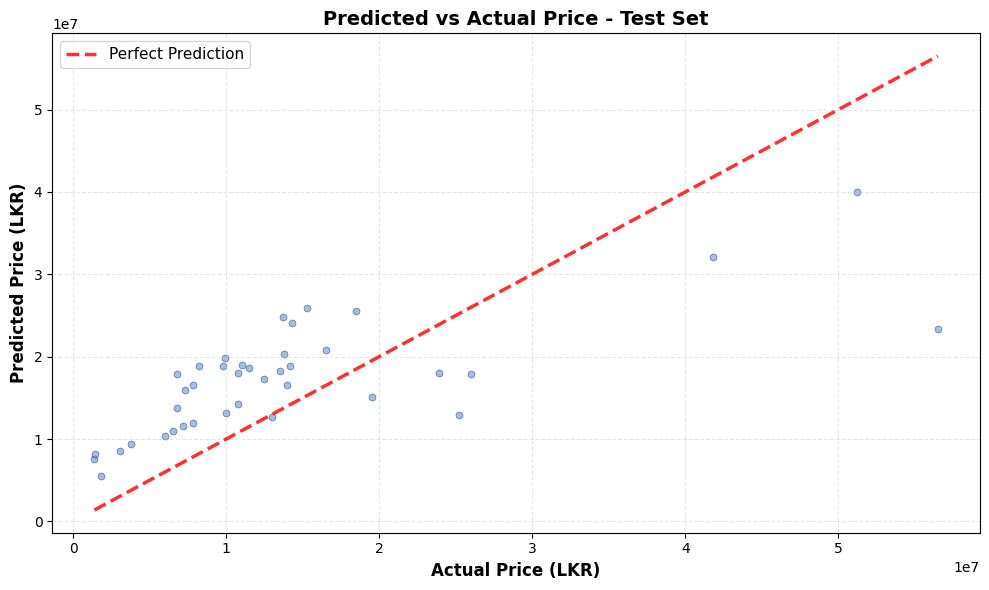

In [19]:
# Plot 1: Predicted vs Actual (Test Set)
print("\nGenerating predicted vs actual scatter plot...")

y_test_pred = best_model.predict(X_test)

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_test_pred, alpha=0.5, s=25, color="steelblue", edgecolors="navy", linewidth=0.5)

# Add perfect prediction line
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], "r--", lw=2.5, label="Perfect Prediction", alpha=0.8)

plt.xlabel("Actual Price (LKR)", fontsize=12, fontweight="bold")
plt.ylabel("Predicted Price (LKR)", fontsize=12, fontweight="bold")
plt.title("Predicted vs Actual Price - Test Set", fontsize=14, fontweight="bold")
plt.legend(fontsize=11, loc="upper left")
plt.grid(True, alpha=0.3, linestyle="--")
plt.tight_layout()
plt.savefig("predicted_vs_actual.png", dpi=300, bbox_inches="tight")
print("Saved: predicted_vs_actual.png")
plt.show()


Generating feature importance plot...
Saved: feature_importance_top20.png


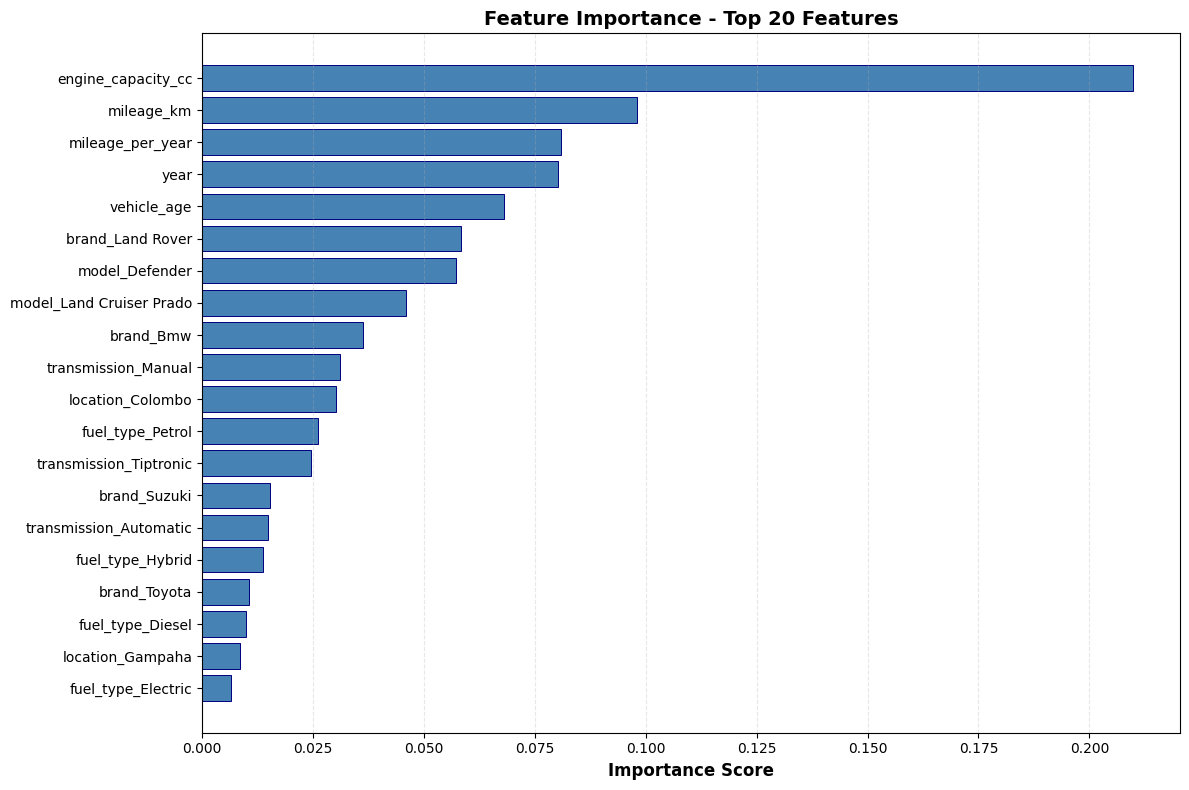

In [20]:
# Plot 2: Feature Importance (Top 20)
print("\nGenerating feature importance plot...")

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
}).sort_values("Importance", ascending=False)

# Top 20 features
top_20 = feature_importance.head(20)

plt.figure(figsize=(12, 8))
bars = plt.barh(range(len(top_20)), top_20["Importance"].values, color="steelblue", edgecolor="navy", linewidth=0.7)
plt.yticks(range(len(top_20)), top_20["Feature"].values, fontsize=10)
plt.xlabel("Importance Score", fontsize=12, fontweight="bold")
plt.title("Feature Importance - Top 20 Features", fontsize=14, fontweight="bold")
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis="x", linestyle="--")
plt.tight_layout()
plt.savefig("feature_importance_top20.png", dpi=300, bbox_inches="tight")
print("Saved: feature_importance_top20.png")
plt.show()

In [21]:
# Summary & Selected Hyperparameters
print("\n" + "="*60)
print("SELECTED HYPERPARAMETERS (from GridSearchCV)")
print("="*60)
for param, value in grid_search.best_params_.items():
    print(f"{param:.<35} {value}")
print("="*60)

print("\n✓ Model training and evaluation complete!")
print("\nGenerated Outputs:")
print("  1. Evaluation Results Table (displayed above)")
print("  2. predicted_vs_actual.png")
print("  3. feature_importance_top20.png")


SELECTED HYPERPARAMETERS (from GridSearchCV)
max_depth.......................... 15
max_features....................... sqrt
min_samples_leaf................... 2
min_samples_split.................. 5
n_estimators....................... 200

✓ Model training and evaluation complete!

Generated Outputs:
  1. Evaluation Results Table (displayed above)
  2. predicted_vs_actual.png
  3. feature_importance_top20.png
